In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## GRU

### Battery Drain Comparison

#### Statistics

In [2]:
df = pd.read_csv("./LOCAL_GRU.csv")
df.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness,battery_drain,predicted_drain_average,inference_time_ms,batch
0,4/23/2026 22:20,26,67,36.3,50,1,0.650718,0.000000,1,21,3949,1095.76920,17.185885,1
1,4/23/2026 22:20,26,66,36.6,51,1,0.594367,0.374730,1,21,3969,1049.32600,9.546042,1
2,4/23/2026 22:20,35,67,36.6,51,1,0.044356,0.030857,1,21,3923,1006.00604,1.387604,1
3,4/23/2026 22:20,26,67,36.6,51,1,0.769046,0.574363,1,21,3964,972.66850,6.067604,1
4,4/23/2026 22:20,26,67,36.8,51,1,0.433491,0.546933,1,21,3940,943.25060,5.578020,1


In [3]:
shift_step = 15
df_eval = df.copy()
df_eval['actual_aligned'] = df_eval['battery_drain'].shift(-shift_step)
df_eval = df_eval.dropna(subset=['actual_aligned', 'predicted_drain_average'])

In [4]:
df_eval[['actual_aligned', 'predicted_drain_average']].mean()

actual_aligned             -5.929852
predicted_drain_average   -44.272228
dtype: float64

In [5]:
# Not Charging
df_eval[df_eval['battery_charging'] != 1][
    ['actual_aligned', 'predicted_drain_average']
].mean()

actual_aligned            -261.823742
predicted_drain_average   -300.981161
dtype: float64

In [6]:
# Charging
df_eval[df_eval['battery_charging'] == 1][
    ['actual_aligned', 'predicted_drain_average']
].mean()

actual_aligned             1432.502497
predicted_drain_average    1398.741639
dtype: float64

In [7]:
charging = df_eval[df_eval['battery_charging'] == 1]
not_charging = df_eval[df_eval['battery_charging'] != 1]

In [8]:
def percentage_diff(df):
    actual_mean = df['actual_aligned'].mean()
    pred_mean = df['predicted_drain_average'].mean()

    perc = abs(actual_mean - pred_mean) / abs(actual_mean) * 100

    return actual_mean, pred_mean, perc

In [9]:
act_c, pred_c, perc_c = percentage_diff(charging)
act_nc, pred_nc, perc_nc = percentage_diff(not_charging)
act_all, pred_all, perc_all = percentage_diff(df_eval)

In [10]:
print("== ALL ===")
print("Actual Mean:", act_all)
print("Predicted Mean:", pred_all)
print("Percentage Difference:", perc_all, "%")

print("\n=== CHARGING ===")
print("Actual Mean:", act_c)
print("Predicted Mean:", pred_c)
print("Percentage Difference:", perc_c, "")

print("\n=== NOT CHARGING ===")
print("Actual Mean:", act_nc)
print("Predicted Mean:", pred_nc)
print("Percentage Difference:", perc_nc, "%")

== ALL ===
Actual Mean: -5.929852045256745
Predicted Mean: -44.272228450643034
Percentage Difference: 646.5992087619815 %

=== CHARGING ===
Actual Mean: 1432.5024971187092
Predicted Mean: 1398.7416394083748
Percentage Difference: 2.35677478944993 

=== NOT CHARGING ===
Actual Mean: -261.8237424822307
Predicted Mean: -300.9811607932499
Percentage Difference: 14.955640745100371 %


#### Graph

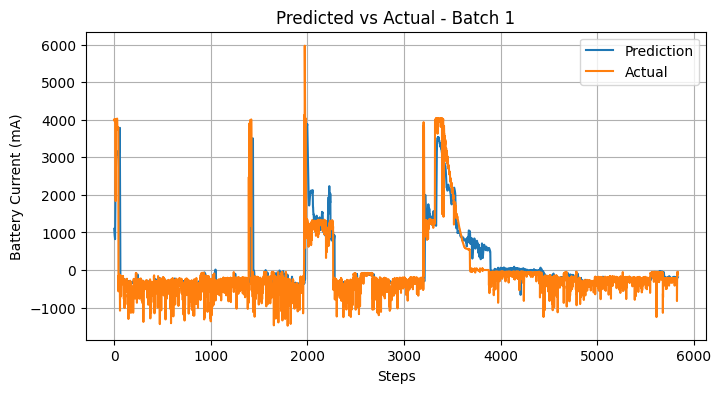

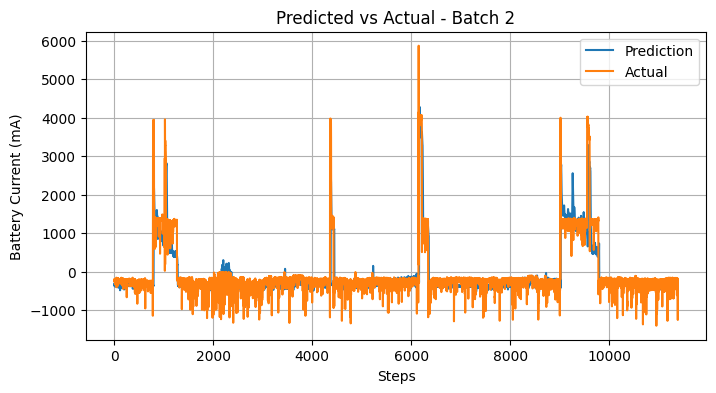

In [11]:
# Predicted vs Actual Graph
batch_num = df['batch'].nunique()

for i in range(1, batch_num + 1):
    batch_df = df[df['batch'] == i].copy()

    actual = batch_df['battery_drain'].shift(-shift_step)
    predicted = batch_df['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    plt.figure(figsize=(8, 4))
    plt.plot(predicted, label="Prediction")
    plt.plot(actual, label="Actual")
    plt.title(f"Predicted vs Actual - Batch {i}")
    plt.xlabel("Steps")
    plt.ylabel("Battery Current (mA)")
    plt.legend()
    plt.grid(True)
    plt.show()

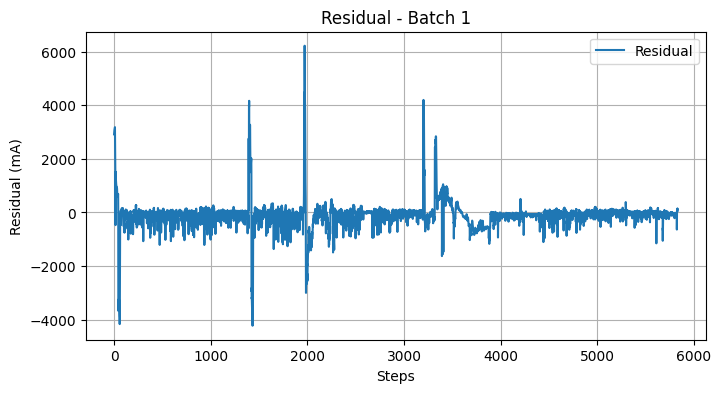

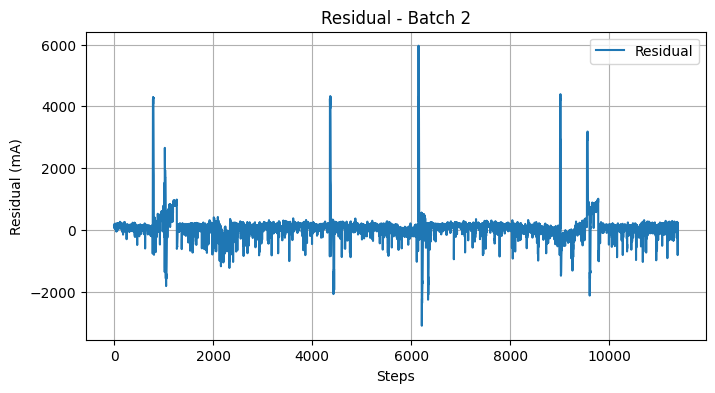

In [12]:
# Residual Graph
for i in range(1, batch_num + 1):
    batch_df = df[df['batch'] == i].copy()

    actual = batch_df['battery_drain'].shift(-shift_step)
    predicted = batch_df['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    residual = actual - predicted

    plt.figure(figsize=(8, 4))
    plt.plot(residual, label="Residual")
    plt.title(f"Residual - Batch {i}")
    plt.xlabel("Steps")
    plt.ylabel("Residual (mA)")
    plt.legend()
    plt.grid(True)
    plt.show()

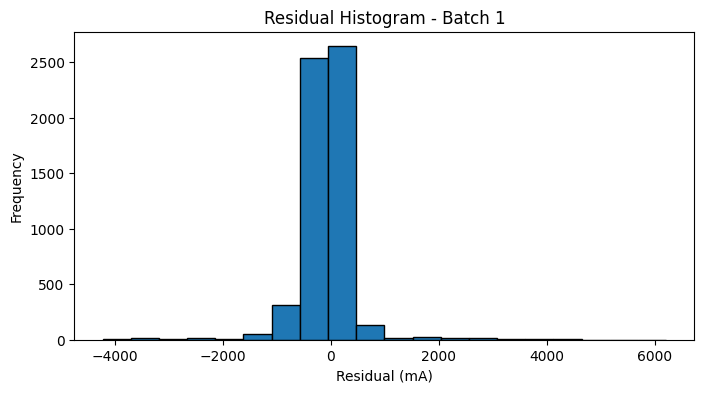

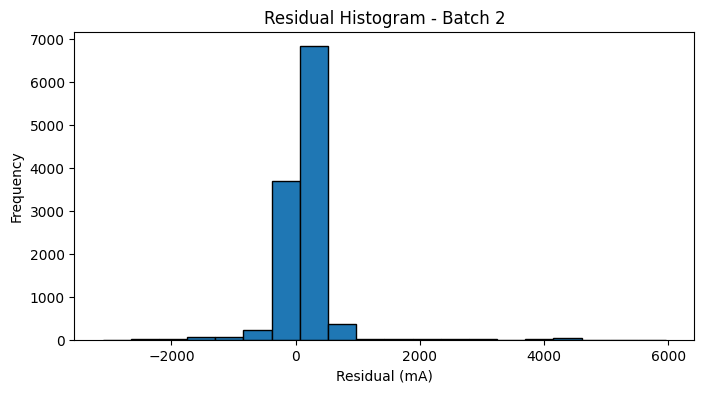

In [24]:
#Residual Histogram
for i in range(1, batch_num + 1):
    batch_df = df[df['batch'] == i].copy()

    actual = batch_df['battery_drain'].shift(-shift_step)
    predicted = batch_df['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    residual = actual - predicted

    plt.figure(figsize=(8, 4))
    plt.hist(residual, bins=20, edgecolor='black')
    plt.xlabel("Residual (mA)")
    plt.ylabel("Frequency")
    plt.title(f"Residual Histogram - Batch {i}")

Correlation: 0.8139497832041691


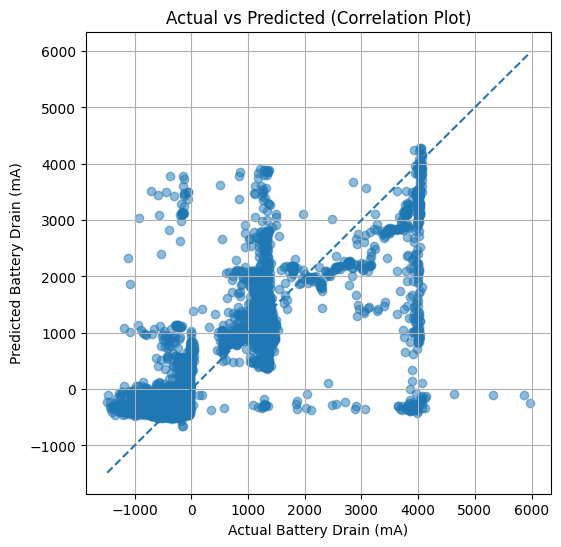

In [28]:
# Scatter Plot
actual_all = df_eval['battery_drain'].shift(-shift_step)
predicted_all = df_eval['predicted_drain_average']

valid_idx = actual_all.notna()
actual_all = actual_all[valid_idx].values
predicted_all = predicted_all[valid_idx].values

plt.figure(figsize=(6,6))
plt.scatter(actual_all, predicted_all, alpha=0.5)
min_val = min(actual_all.min(), predicted_all.min())
max_val = max(actual_all.max(), predicted_all.max())
plt.xlabel("Actual Battery Drain (mA)")
plt.ylabel("Predicted Battery Drain (mA)")
plt.title("Actual vs Predicted (Correlation Plot)")
plt.grid(True)
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
print("Correlation:", np.corrcoef(actual_all, predicted_all)[0,1])

### Time Inference

#### Statistics

In [29]:
# Inference
df['inference_time_ms'].describe()

count    17250.000000
mean         2.701647
std          1.715547
min          0.526355
25%          1.359037
50%          1.865391
75%          4.112774
max         22.897084
Name: inference_time_ms, dtype: float64

#### Graph

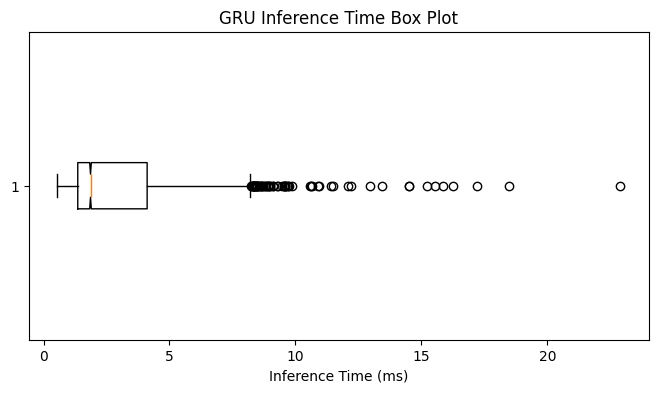

In [30]:
plt.figure(figsize=(8, 4))
plt.boxplot(df['inference_time_ms'], notch=True, vert=False)
plt.title("GRU Inference Time Box Plot")
plt.xlabel("Inference Time (ms)")
plt.show()

## CNN GRU

### Battery Drain Comparison

#### Statistics

In [31]:
df_cnn = pd.read_csv("./LOCAL_CNN_GRU.csv")
df_cnn.head()

,timestamp,cpu_usage,memory_usage,temperature,battery_level,battery_charging,upload_speed_kbps,download_speed_kbps,screen_on,brightness,battery_drain,predicted_drain_average,inference_time_ms,batch
0,4/24/2026 11:29,53,69,34.0,48,0,9.745290,9.724471,1,23,-329,-256.58835,2.877448,1
1,4/24/2026 11:29,37,68,34.0,48,0,3.566566,0.894737,1,23,-273,-255.10776,3.124479,1
2,4/24/2026 11:29,35,68,34.0,48,0,0.231017,0.209972,1,23,-288,-301.81644,3.529896,1
3,4/24/2026 11:29,39,69,34.0,48,0,0.439453,0.369112,1,23,-260,-300.23970,1.408750,1
4,4/24/2026 11:30,49,68,34.0,48,0,0.129287,0.129287,1,23,-256,-278.74072,1.260417,1


In [32]:
shift_step = 15
df_eval_cnn = df_cnn.copy()
df_eval_cnn['actual_aligned'] = df_eval_cnn['battery_drain'].shift(-shift_step)
df_eval_cnn = df_eval_cnn.dropna(subset=['actual_aligned', 'predicted_drain_average'])

In [33]:
df_eval_cnn[['actual_aligned', 'predicted_drain_average']].mean()

actual_aligned             13.003717
predicted_drain_average    13.487897
dtype: float64

In [34]:
# Not Charging
df_eval_cnn[df_eval_cnn['battery_charging'] != 1][['actual_aligned', 'predicted_drain_average']].mean()

actual_aligned            -286.442893
predicted_drain_average   -240.551000
dtype: float64

In [35]:
# Charging
df_eval_cnn[df_eval_cnn['battery_charging'] == 1][['actual_aligned', 'predicted_drain_average']].mean()

actual_aligned             2065.154680
predicted_drain_average    1754.453234
dtype: float64

In [36]:
charging_cnn = df_eval_cnn[df_eval_cnn['battery_charging'] == 1]
not_charging_cnn = df_eval_cnn[df_eval_cnn['battery_charging'] != 1]

In [37]:
act_c_cnn, pred_c_cnn, perc_c_cnn = percentage_diff(charging)
act_nc_cnn, pred_nc_cnn, perc_nc_cnn = percentage_diff(not_charging)
act_all_cnn, pred_all_cnn, perc_all_cnn = percentage_diff(df_eval_cnn)

In [38]:
print("== ALL ===")
print("Actual Mean:", act_all_cnn)
print("Predicted Mean:", pred_all_cnn)
print("Percentage Difference:", perc_all_cnn, "%")

print("\n=== CHARGING ===")
print("Actual Mean:", act_c_cnn)
print("Predicted Mean:", pred_c_cnn)
print("Percentage Difference:", perc_c_cnn, "%")

print("\n=== NOT CHARGING ===")
print("Actual Mean:", act_nc_cnn)
print("Predicted Mean:", pred_nc_cnn)
print("Percentage Difference:", perc_nc_cnn, "%")

== ALL ===
Actual Mean: 13.003717044757817
Predicted Mean: 13.487897245268327
Percentage Difference: 3.723398462485749 %

=== CHARGING ===
Actual Mean: 1432.5024971187092
Predicted Mean: 1398.7416394083748
Percentage Difference: 2.35677478944993 %

=== NOT CHARGING ===
Actual Mean: -261.8237424822307
Predicted Mean: -300.9811607932499
Percentage Difference: 14.955640745100371 %


#### Graph

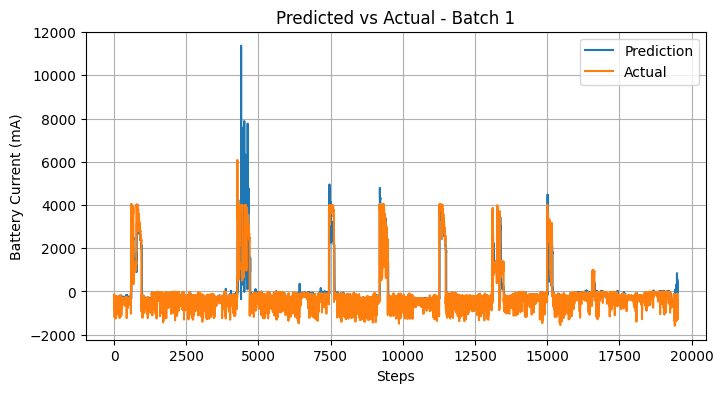

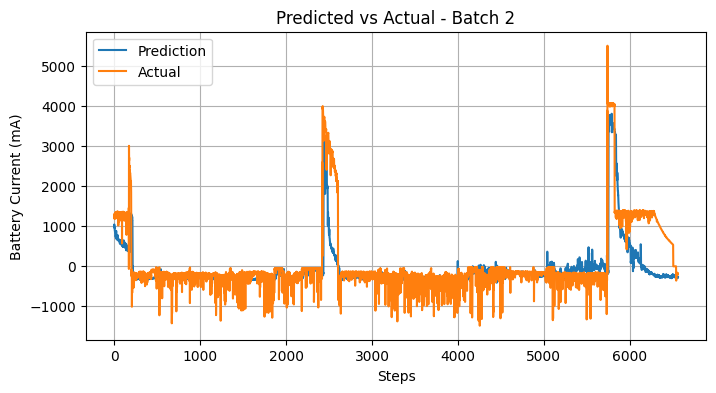

In [39]:
batch_num_cnn = df_cnn['batch'].nunique()

for i in range(1, batch_num_cnn + 1):
    batch_df_cnn = df_cnn[df_cnn['batch'] == i].copy()

    actual = batch_df_cnn['battery_drain'].shift(-shift_step)
    predicted = batch_df_cnn['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    plt.figure(figsize=(8, 4))
    plt.plot(predicted, label="Prediction")
    plt.plot(actual, label="Actual")
    plt.title(f"Predicted vs Actual - Batch {i}")
    plt.xlabel("Steps")
    plt.ylabel("Battery Current (mA)")
    plt.legend()
    plt.grid(True)
    plt.show()

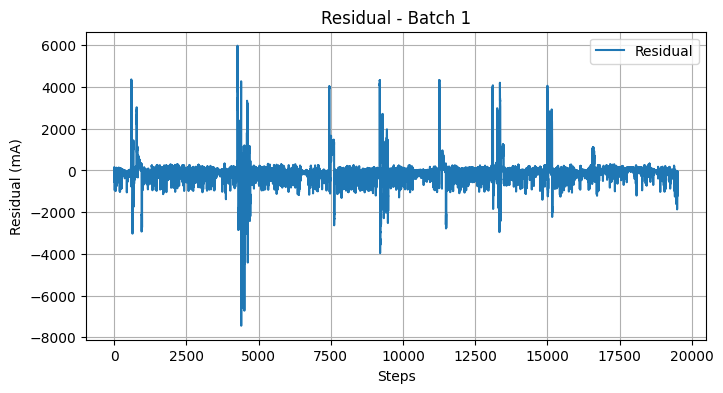

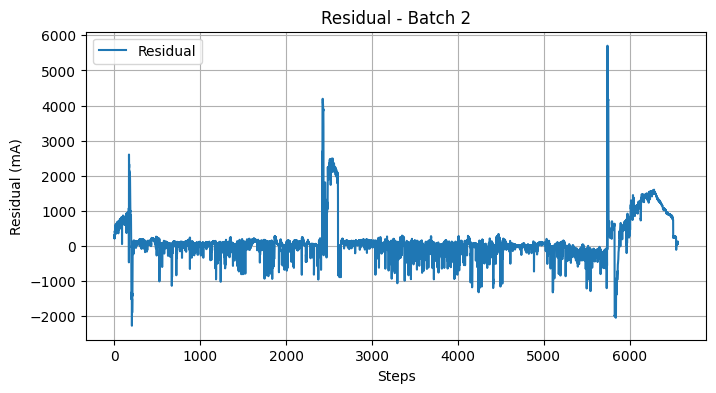

In [40]:
for i in range(1, batch_num + 1):
    batch_df_cnn = df_cnn[df_cnn['batch'] == i].copy()

    actual = batch_df_cnn['battery_drain'].shift(-shift_step)
    predicted = batch_df_cnn['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    residual = actual - predicted

    plt.figure(figsize=(8, 4))
    plt.plot(residual, label="Residual")
    plt.title(f"Residual - Batch {i}")
    plt.xlabel("Steps")
    plt.ylabel("Residual (mA)")
    plt.legend()
    plt.grid(True)
    plt.show()

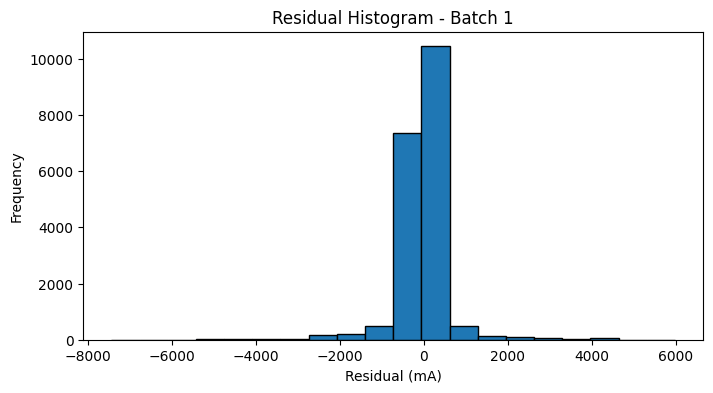

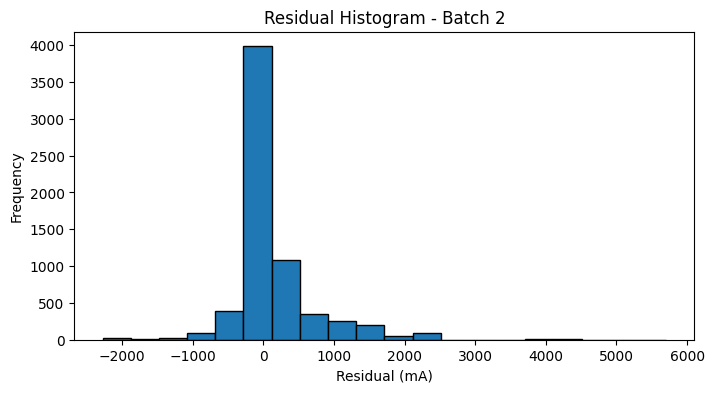

In [41]:
#Residual Histogram
for i in range(1, batch_num + 1):
    batch_df_cnn = df_cnn[df_cnn['batch'] == i].copy()

    actual = batch_df_cnn['battery_drain'].shift(-shift_step)
    predicted = batch_df_cnn['predicted_drain_average']

    valid_idx = actual.notna()
    actual = actual[valid_idx].values
    predicted = predicted[valid_idx].values

    residual = actual - predicted

    plt.figure(figsize=(8, 4))
    plt.hist(residual, bins=20, edgecolor='black')
    plt.xlabel("Residual (mA)")
    plt.ylabel("Frequency")
    plt.title(f"Residual Histogram - Batch {i}")

Correlation: 0.7960365490301179


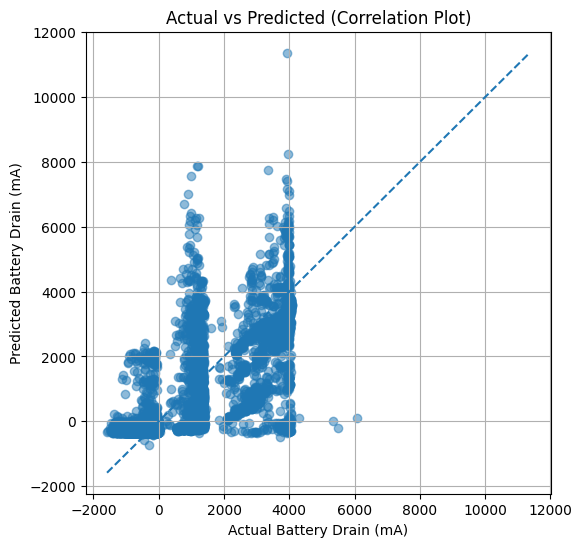

In [43]:
# Scatter Plot
actual_all = df_eval_cnn['battery_drain'].shift(-shift_step)
predicted_all = df_eval_cnn['predicted_drain_average']

valid_idx = actual_all.notna()
actual_all = actual_all[valid_idx].values
predicted_all = predicted_all[valid_idx].values

plt.figure(figsize=(6,6))
plt.scatter(actual_all, predicted_all, alpha=0.5)
min_val = min(actual_all.min(), predicted_all.min())
max_val = max(actual_all.max(), predicted_all.max())
plt.xlabel("Actual Battery Drain (mA)")
plt.ylabel("Predicted Battery Drain (mA)")
plt.title("Actual vs Predicted (Correlation Plot)")
plt.grid(True)
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
print("Correlation:", np.corrcoef(actual_all, predicted_all)[0,1])

### Time Inference

#### Statistics

In [44]:
# Inference
df_cnn['inference_time_ms'].describe()

count    26111.000000
mean         1.882758
std          1.341724
min          0.345520
25%          0.881797
50%          1.373282
75%          2.818932
max         49.664948
Name: inference_time_ms, dtype: float64

#### Graph

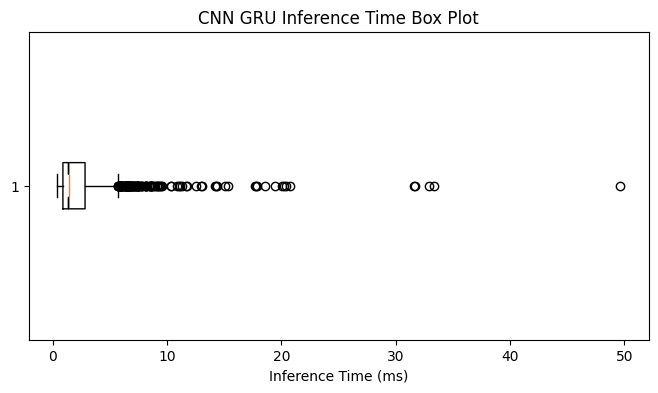

In [45]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_cnn['inference_time_ms'], notch=True, vert=False)
plt.title("CNN GRU Inference Time Box Plot")
plt.xlabel("Inference Time (ms)")
plt.show()